# Micromouse — maze photo → drive commands

Turns a single overhead photo of the maze into a wall-accurate map, a shortest path,
and the `f`/`l`/`r` string that `chainMovement()` in `task3ChainingMovements.hpp` executes.

**Pipeline**

| stage | what happens |
|---|---|
| 1 | find the rig in the photo and flatten the perspective |
| 2 | locate the cyan wall clips → infer the grid size and spacing |
| 3 | one homography: photo → exact `N·CELL_PX` maze square |
| 4 | illumination-flattened wall mask |
| 5 | score each of the `2·N·(N+1)` cell edges → boolean wall map |
| 6 | walls → graph, BFS shortest path, flood-fill distances |
| 7 | path → `f`/`l`/`r` command string, exported for the firmware |

Nothing is hard-coded to this photo: the grid size, the maze corners and the cell
pitch are all measured from the image.

In [37]:
import math
import textwrap
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ----------------------------------------------------------------- tunables
PHOTO       = "maze_1.jpg"

CELL_PX     = 100          # px per maze cell in the rectified image
COARSE_PX   = 900          # size of the first (rig) rectification

CLIP_HUE    = (78, 110)    # OpenCV hue window for the cyan wall clips
CLIP_SAT    = 70
CLIP_VAL    = 80
CLIP_AREA   = 25           # min blob area (px) to count as a clip
CLIP_TOL    = 25           # px: clips closer than this share a grid line

WALL_LEVEL  = 200          # flattened-gray below this = wall pixel
EDGE_HALF   = 22           # px band either side of a cell edge when scoring
EDGE_TRIM   = 0.22         # ignore this fraction at each end (posts/corners)
WALL_THR    = 0.50         # fraction of the edge that must be dark

# Start pose is (row, col, direction) and the goal is (row, col), both zero-indexed
# with row 0 at the top (north) of the photo -- the convention in the task brief.
# START = (1, 6, "N") therefore means 2nd row, 7th column, facing north.
START, START_HEADING, GOAL = (1, 6), "W", (5, 2)

# The brief specifies the goal as (row, col) only, so the final heading is free.
# Set this to "N"/"E"/"S"/"W" to also park the robot facing a given way.
GOAL_HEADING = None

PATH_DOT = "\u2022"

plt.rcParams["figure.dpi"] = 110
print("OpenCV", cv2.__version__, "| NumPy", np.__version__)

OpenCV 5.0.0 | NumPy 2.4.4


## Stage 1 — find the rig and flatten it

The rig is by far the largest bright object in the frame, so: threshold → largest
connected component → fill holes → 4-point polygon. That quad is the perspective
reference. No hand-typed pixel coordinates, and it re-derives itself for a
re-shot photo.

In [38]:
def order_quad(pts):
    """Return the 4 points ordered top-left, top-right, bottom-right, bottom-left."""
    p = np.asarray(pts, np.float32).reshape(-1, 2)
    s, d = p.sum(axis=1), p[:, 0] - p[:, 1]
    return np.float32([p[np.argmin(s)],    # tl: smallest x+y
                       p[np.argmax(d)],    # tr: largest  x-y
                       p[np.argmax(s)],    # br: largest  x+y
                       p[np.argmin(d)]])   # bl: smallest x-y


def largest_bright_blob(bgr, level):
    """Binary mask of the biggest bright region, with interior holes filled."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    mask = cv2.morphologyEx((gray > level).astype(np.uint8) * 255,
                            cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8))

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    biggest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (labels == biggest).astype(np.uint8) * 255

    # flood the outside from a corner, then invert it to get the holes
    flooded = mask.copy()
    cv2.floodFill(flooded, np.zeros((h + 2, w + 2), np.uint8), (0, 0), 255)
    return mask | cv2.bitwise_not(flooded)


def find_rig_quad(bgr, level=130):
    mask = largest_bright_blob(bgr, level)
    contour = max(cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea)

    quad = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
    if len(quad) != 4:                       # fall back if the outline is noisy
        quad = cv2.boxPoints(cv2.minAreaRect(contour))
    return order_quad(quad)


def square_transform(quad, size):
    """Homography mapping `quad` onto a `size` x `size` square."""
    return cv2.getPerspectiveTransform(
        quad, np.float32([[0, 0], [size, 0], [size, size], [0, size]]))

rig corners (tl, tr, br, bl):
  tl  (  540.0,   122.0)
  tr  ( 1423.0,   129.0)
  br  ( 1392.0,   998.0)
  bl  (  539.0,   972.0)


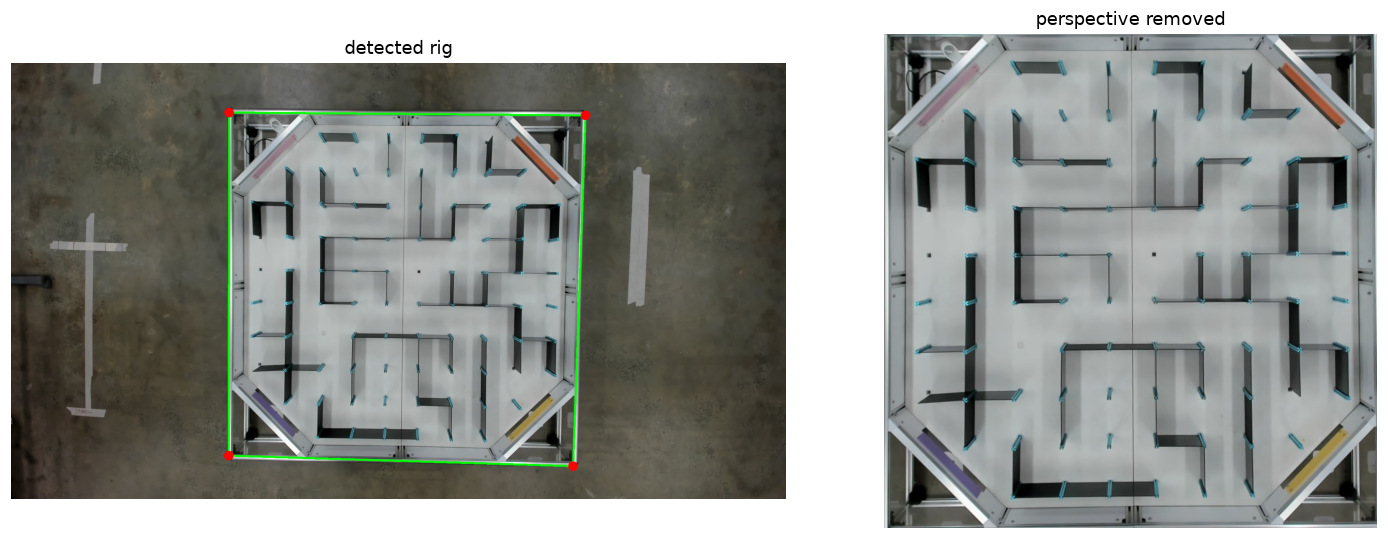

In [39]:
photo = cv2.imread(PHOTO)
if photo is None:
    raise FileNotFoundError(f"could not read {PHOTO!r} - run this notebook from src/task4_code/")

rig_quad = find_rig_quad(photo)
M_coarse = square_transform(rig_quad, COARSE_PX)
coarse   = cv2.warpPerspective(photo, M_coarse, (COARSE_PX, COARSE_PX))

print("rig corners (tl, tr, br, bl):")
for name, (x, y) in zip("tl tr br bl".split(), rig_quad):
    print(f"  {name}  ({x:7.1f}, {y:7.1f})")

marked = photo.copy()
cv2.polylines(marked, [rig_quad.astype(int)], True, (0, 255, 0), 4)
for x, y in rig_quad.astype(int):
    cv2.circle(marked, (x, y), 12, (0, 0, 255), -1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB)); ax[0].set_title("detected rig")
ax[1].imshow(cv2.cvtColor(coarse, cv2.COLOR_BGR2RGB)); ax[1].set_title("perspective removed")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Stage 2 — read the grid off the wall clips

Every wall is held by a pair of cyan clips, and those clips sit on cell corners.
Isolating them by hue and clustering their centres in x and y recovers the grid
lines directly from the hardware — which is far more reliable than assuming the
maze fills the board.

This maze is 9 × 9, but rows and columns are counted **independently** and
`ROWS`/`COLS` are carried separately from here on, so the size is measured rather
than asserted and a re-shot or differently-shaped board needs no code change.

In [40]:
def find_clips(bgr):
    """Centroids of the cyan wall clips."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hue, sat, val = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    mask = ((hue > CLIP_HUE[0]) & (hue < CLIP_HUE[1]) &
            (sat > CLIP_SAT) & (val > CLIP_VAL)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    n, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    return np.array([centroids[i] for i in range(1, n)
                     if stats[i, cv2.CC_STAT_AREA] >= CLIP_AREA])


def cluster_1d(values, tol):
    """Collapse 1-D values into groups whose neighbours are within `tol`."""
    ordered = np.sort(np.asarray(values, float))
    groups = [[ordered[0]]]
    for v in ordered[1:]:
        if v - groups[-1][-1] <= tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return np.array([np.mean(g) for g in groups])


def infer_grid(clips, tol=CLIP_TOL):
    """Grid line positions (xs, ys) implied by the clip centroids."""
    return cluster_1d(clips[:, 0], tol), cluster_1d(clips[:, 1], tol)

64 clips  ->  9 rows x 9 cols
x lines: [ 63.6 153.7 239.3 325.3 411.  495.5 580.4 664.9 751.  839. ]
y lines: [ 58.4 145.3 229.6 315.1 401.3 486.7 573.7 660.5 745.5 835.6]
cell pitch: 86.2 px (x), 86.4 px (y)


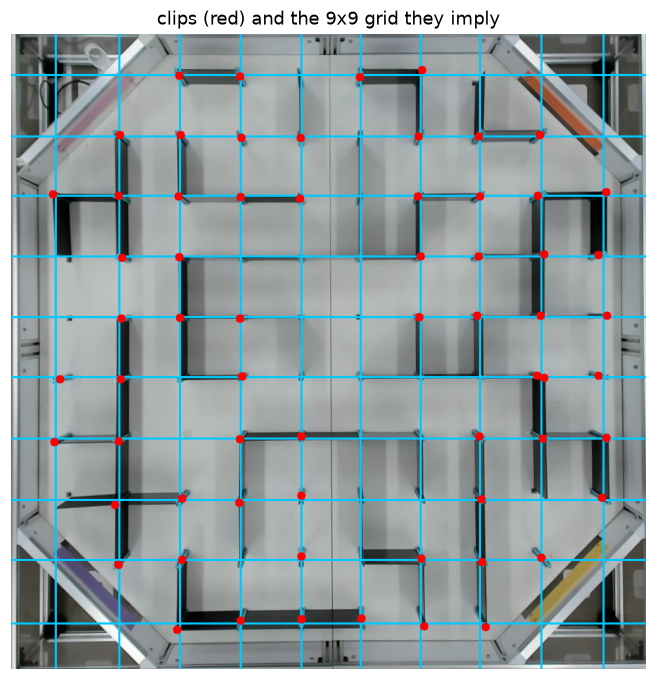

In [41]:
clips  = find_clips(coarse)
gx, gy = infer_grid(clips)

# Counted independently rather than assumed equal, so the size comes from the
# photo. For this board both come out as 9.
COLS, ROWS = len(gx) - 1, len(gy) - 1
if ROWS < 2 or COLS < 2:
    raise RuntimeError(f"implausible {ROWS} x {COLS} grid from {len(clips)} clips "
                       "- widen CLIP_TOL or the hue window")

print(f"{len(clips)} clips  ->  {ROWS} rows x {COLS} cols")
print("x lines:", np.round(gx, 1))
print("y lines:", np.round(gy, 1))
print("cell pitch: %.1f px (x), %.1f px (y)" % (np.diff(gx).mean(), np.diff(gy).mean()))

vis = coarse.copy()
for x in gx: cv2.line(vis, (int(x), 0), (int(x), COARSE_PX), (255, 200, 0), 2)
for y in gy: cv2.line(vis, (0, int(y)), (COARSE_PX, int(y)), (255, 200, 0), 2)
for x, y in clips.astype(int): cv2.circle(vis, (x, y), 6, (0, 0, 255), -1)

plt.figure(figsize=(7.5, 7.5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"clips (red) and the {ROWS}x{COLS} grid they imply")
plt.axis("off"); plt.show()

## Stage 3 — one homography, photo → maze square

Rather than warping twice and losing sharpness, the rig transform and the
grid-fitting transform are multiplied into a single matrix `M`. The result is a
square where **cell `(r, c)` is exactly the box `[c·CELL_PX, (c+1)·CELL_PX] ×
[r·CELL_PX, (r+1)·CELL_PX]`** — so every later step is plain array slicing.

rectified maze: 900 x 900 px, 100 px per cell


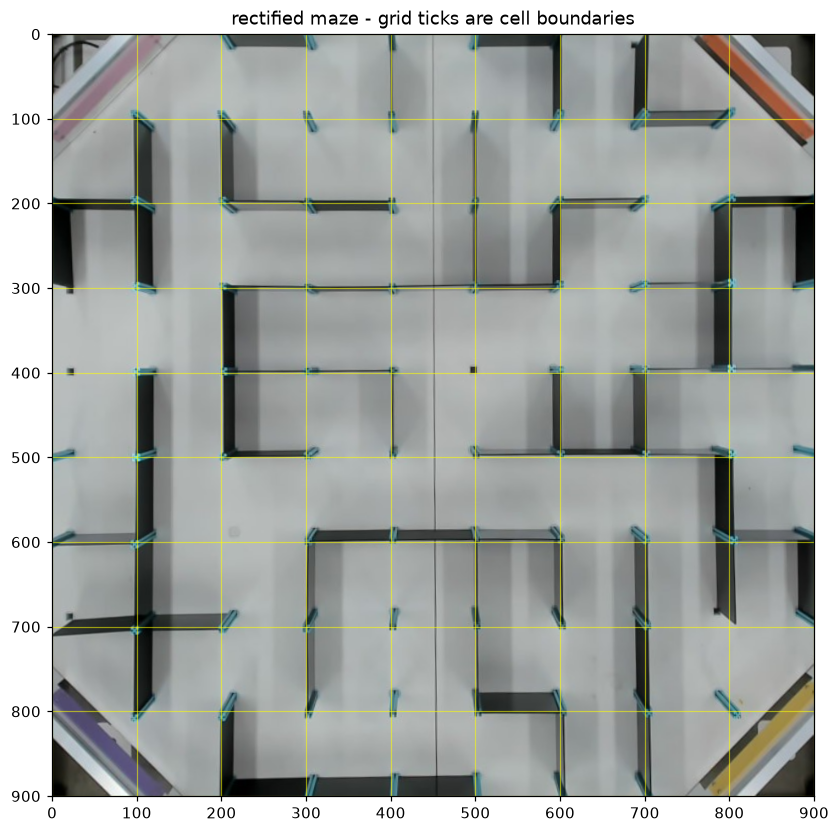

In [42]:
MAZE_W, MAZE_H = COLS * CELL_PX, ROWS * CELL_PX
grid_quad = np.float32([[gx[0],  gy[0]],  [gx[-1], gy[0]],
                        [gx[-1], gy[-1]], [gx[0],  gy[-1]]])

M = cv2.getPerspectiveTransform(
        grid_quad,
        np.float32([[0, 0], [MAZE_W, 0], [MAZE_W, MAZE_H], [0, MAZE_H]])) @ M_coarse
maze_img = cv2.warpPerspective(photo, M, (MAZE_W, MAZE_H))

def cell_centre(r, c):
    return int((c + 0.5) * CELL_PX), int((r + 0.5) * CELL_PX)

print(f"rectified maze: {maze_img.shape[1]} x {maze_img.shape[0]} px, {CELL_PX} px per cell")

plt.figure(figsize=(8 * COLS / max(ROWS, COLS) + 2, 8 * ROWS / max(ROWS, COLS) + 1))
plt.imshow(cv2.cvtColor(maze_img, cv2.COLOR_BGR2RGB))
plt.xticks(np.arange(0, MAZE_W + 1, CELL_PX)); plt.yticks(np.arange(0, MAZE_H + 1, CELL_PX))
plt.grid(color="yellow", alpha=.55)
plt.title("rectified maze - grid ticks are cell boundaries")
plt.show()

## Stage 4 — wall pixels

The board is lit unevenly (bright at the top, shadowed at the bottom), so a fixed
grey threshold cannot separate wall from floor across the whole image. A
morphological *closing* with a kernel wider than any wall estimates the local
floor brightness; dividing by it flattens the lighting and leaves a threshold
that works everywhere.

wall pixels: 19.1% of the board


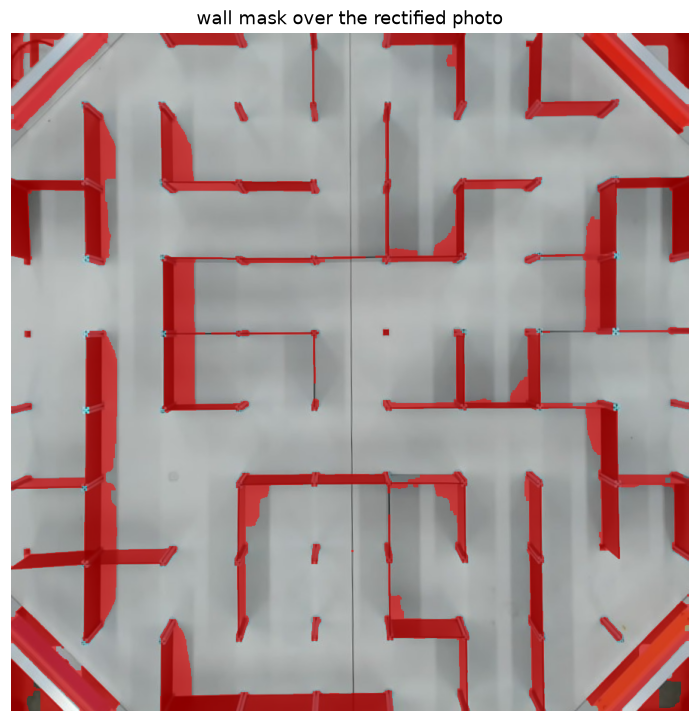

In [43]:
def wall_pixels(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # closing with a kernel wider than a wall keeps only the floor -> local brightness
    floor = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((61, 61), np.uint8))
    flat  = cv2.divide(gray, floor, scale=255)

    mask = (flat < WALL_LEVEL).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))   # speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))   # seams
    return mask


wall_mask = wall_pixels(maze_img)
print(f"wall pixels: {wall_mask.mean():.1%} of the board")

tint = maze_img.copy(); tint[wall_mask > 0] = (0, 0, 255)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.addWeighted(maze_img, .45, tint, .55, 0), cv2.COLOR_BGR2RGB))
plt.title("wall mask over the rectified photo"); plt.axis("off"); plt.show()

## Stage 5 — from pixels to a wall map

This is the step the old ray-casting approach got wrong. Sampling a straight line
between two cell centres asks *"is anything dark in the way"*, which fires on the
side face of a neighbouring wall and misses walls the line clips at an angle.

Instead each **cell edge** is scored on its own. For the edge between two cells we
take a band `±EDGE_HALF` px around it, collapse it along the short axis (so a wall
counts wherever it falls inside the band — this absorbs the parallax lean of a
5 cm wall seen from a camera that is not directly above it), and ask what
fraction of the edge's length is covered.

The ends are trimmed by `EDGE_TRIM`, because the clips and any perpendicular wall
meeting at that corner would otherwise vote for a wall that is not there.

In [44]:
def edge_score(mask, kind, r, c):
    """Covered fraction of one cell edge.

    kind 'H' -> the horizontal edge on the NORTH side of cell (r, c)
    kind 'V' -> the vertical   edge on the WEST  side of cell (r, c)
    """
    trim = int(CELL_PX * EDGE_TRIM)

    if kind == "H":
        y, x0, x1 = r * CELL_PX, c * CELL_PX, (c + 1) * CELL_PX
        band  = mask[max(0, y - EDGE_HALF):y + EDGE_HALF + 1, x0 + trim:x1 - trim]
        along = band.max(axis=0)          # per column: any wall pixel in the band?
    else:
        x, y0, y1 = c * CELL_PX, r * CELL_PX, (r + 1) * CELL_PX
        band  = mask[y0 + trim:y1 - trim, max(0, x - EDGE_HALF):x + EDGE_HALF + 1]
        along = band.max(axis=1)

    return float(along.mean()) if along.size else 0.0


def build_walls(mask, rows, cols):
    """Score every edge, then threshold into two boolean wall maps.

    H[r, c] - wall on the north side of (r, c);  shape (rows+1, cols)
    V[r, c] - wall on the west  side of (r, c);  shape (rows, cols+1)
    """
    h_score = np.array([[edge_score(mask, "H", r, c) for c in range(cols)] for r in range(rows + 1)])
    v_score = np.array([[edge_score(mask, "V", r, c) for c in range(cols + 1)] for r in range(rows)])

    H, V = h_score >= WALL_THR, v_score >= WALL_THR

    # the board edge is a physical barrier even where no wall is clipped to it
    H[0, :] = H[-1, :] = True
    V[:, 0] = V[:, -1] = True
    return H, V, h_score, v_score


H, V, h_score, v_score = build_walls(wall_mask, ROWS, COLS)
print(f"walls found: {H.sum()} horizontal, {V.sum()} vertical "
      f"(of {H.size} and {V.size} possible edges)")

walls found: 48 horizontal, 54 vertical (of 90 and 90 possible edges)


92.2% of edges scored decisively

13 borderline edge(s) - threshold is 0.5:
  0.71  west of cell (8, 1)  ->  WALL
  0.70  west of cell (6, 5)  ->  WALL
  0.66  north of cell (1, 0)  ->  WALL
  0.64  west of cell (0, 1)  ->  WALL
  0.48  west of cell (7, 9)  ->  open
  0.41  north of cell (9, 1)  ->  open
  0.36  north of cell (0, 7)  ->  open
  0.34  north of cell (5, 1)  ->  open
  0.32  north of cell (4, 7)  ->  open
  0.30  west of cell (7, 0)  ->  open
  0.30  north of cell (6, 1)  ->  open
  0.30  north of cell (2, 1)  ->  open
  0.29  north of cell (4, 1)  ->  open


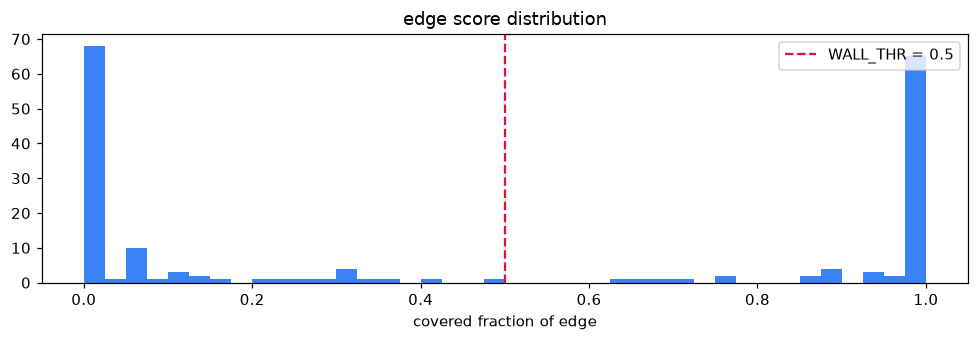

In [45]:
# Scores should sit hard against 0 or 1. Anything mid-range is a judgement call
# worth eyeballing before trusting the map.
def ambiguous(h_score, v_score, lo=0.25, hi=0.75):
    out = []
    for kind, arr in (("H", h_score), ("V", v_score)):
        for (r, c), s in np.ndenumerate(arr):
            if lo < s < hi:
                out.append((s, kind, r, c))
    return sorted(out, reverse=True)


decided = np.concatenate([h_score.ravel(), v_score.ravel()])
print(f"{np.mean((decided < 0.25) | (decided > 0.75)):.1%} of edges scored decisively\n")

flagged = ambiguous(h_score, v_score)
if flagged:
    print(f"{len(flagged)} borderline edge(s) - threshold is {WALL_THR}:")
    for s, kind, r, c in flagged:
        side = "north of" if kind == "H" else "west of"
        print(f"  {s:.2f}  {side} cell ({r}, {c})  ->  {'WALL' if s >= WALL_THR else 'open'}")
else:
    print("no borderline edges")

plt.figure(figsize=(9, 3.2))
plt.hist(decided, bins=40, color="#3b82f6")
plt.axvline(WALL_THR, color="crimson", ls="--", label=f"WALL_THR = {WALL_THR}")
plt.title("edge score distribution"); plt.xlabel("covered fraction of edge")
plt.legend(); plt.tight_layout(); plt.show()

### Does the map match the photo?

Green = wall detected, magenta = open. Every green segment should lie on black
plastic and every magenta segment on bare floor. This is the cell to look at when
a run goes wrong.

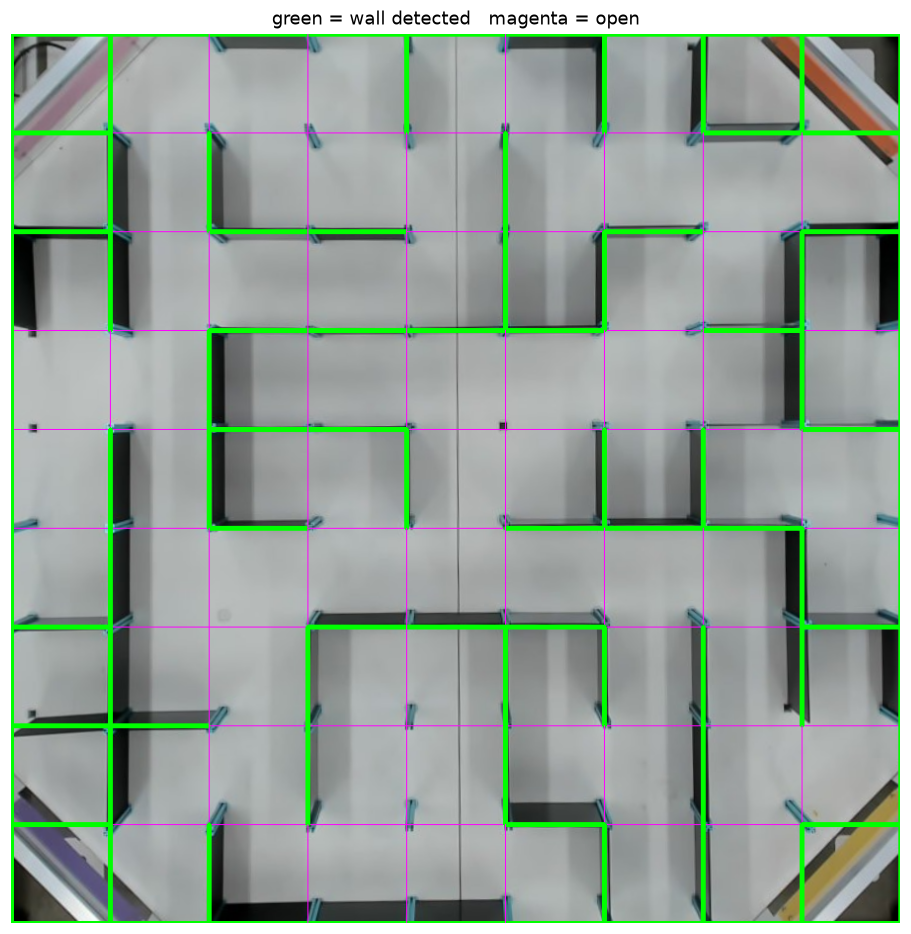

In [46]:
def draw_wall_check(base, H, V):
    vis  = base.copy()
    rows, cols = H.shape[0] - 1, H.shape[1]
    for r in range(rows + 1):
        for c in range(cols):
            on = H[r, c]
            cv2.line(vis, (c * CELL_PX, r * CELL_PX), ((c + 1) * CELL_PX, r * CELL_PX),
                     (0, 255, 0) if on else (255, 0, 255), 4 if on else 1)
    for r in range(rows):
        for c in range(cols + 1):
            on = V[r, c]
            cv2.line(vis, (c * CELL_PX, r * CELL_PX), (c * CELL_PX, (r + 1) * CELL_PX),
                     (0, 255, 0) if on else (255, 0, 255), 4 if on else 1)
    return vis


plt.figure(figsize=(9.5 * COLS / max(ROWS, COLS) + 1, 9.5 * ROWS / max(ROWS, COLS) + 1))
plt.imshow(cv2.cvtColor(draw_wall_check(maze_img, H, V), cv2.COLOR_BGR2RGB))
plt.title("green = wall detected   magenta = open"); plt.axis("off"); plt.show()

## Stage 6 — the maze as a graph

`Maze` owns the wall maps and answers connectivity questions; `Graph` is the
explicit adjacency structure built from it. Node ids follow the existing
convention, `id = row · COLS + col`, so they read left-to-right then top-to-bottom.

Headings are ordered clockwise, which is what makes the turn from any heading to
any other a single modulo-4 subtraction — so **every** starting orientation is
handled, a 180° reversal included.

In [47]:
HEADINGS = ["N", "E", "S", "W"]                                  # clockwise
DELTA    = {"N": (-1, 0), "E": (0, 1), "S": (1, 0), "W": (0, -1)}


class Node:
    def __init__(self, node_id, x, y):
        self.id, self.x, self.y = node_id, x, y

    def get_point(self):
        return self.x, self.y

    def __repr__(self):
        return f"Node({self.id} @ {self.x},{self.y})"


class Graph:
    def __init__(self):
        self.nodes, self.edges = {}, {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges.setdefault(node_id, [])

    def add_edge(self, a, b, weight=1):
        self.edges[a].append((b, weight))

    def remove_edge(self, a, b):
        # the original broke out of the loop after one iteration regardless
        self.edges[a] = [e for e in self.edges[a] if e[0] != b]

    def neighbours(self, node_id):
        return [n for n, _ in self.edges[node_id]]

    def get_edge_weight(self, a, b):
        return next((w for n, w in self.edges[a] if n == b), None)

    def __repr__(self):
        return f"Graph({len(self.nodes)} nodes, {sum(map(len, self.edges.values()))} directed edges)"


class Maze:
    """Wall maps plus the search routines that run on them."""

    def __init__(self, H, V):
        self.H, self.V = H, V
        self.rows, self.cols = H.shape[0] - 1, H.shape[1]

    @property
    def shape(self):
        return self.rows, self.cols

    def inside(self, r, c):
        return 0 <= r < self.rows and 0 <= c < self.cols

    # ---------------------------------------------------------- topology
    def wall(self, r, c, d):
        return bool({"N": self.H[r, c],     "S": self.H[r + 1, c],
                     "W": self.V[r, c],     "E": self.V[r, c + 1]}[d])

    def neighbours(self, r, c):
        for d, (dr, dc) in DELTA.items():
            nr, nc = r + dr, c + dc
            if self.inside(nr, nc) and not self.wall(r, c, d):
                yield (nr, nc), d

    def cells(self):
        for r in range(self.rows):
            for c in range(self.cols):
                yield r, c

    # id = row * cols + col, so ids read left-to-right then top-to-bottom
    def node_id(self, r, c):
        return r * self.cols + c

    def cell(self, node_id):
        return divmod(node_id, self.cols)

    def to_graph(self):
        g = Graph()
        for r, c in self.cells():
            x, y = cell_centre(r, c)
            g.add_node(self.node_id(r, c), x, y)
        for r, c in self.cells():
            for (nr, nc), _ in self.neighbours(r, c):
                g.add_edge(self.node_id(r, c), self.node_id(nr, nc), 1)
        return g

    # ---------------------------------------------------------- search
    def bfs(self, start, goal):
        """Fewest-cells path from start to goal, or None."""
        if start == goal:
            return [start]

        came_from = {start: None}
        queue = deque([start])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if nb in came_from:
                    continue
                came_from[nb] = current
                if nb == goal:
                    path = [nb]
                    while came_from[path[-1]] is not None:
                        path.append(came_from[path[-1]])
                    return path[::-1]
                queue.append(nb)
        return None

    def flood(self, goal):
        """Classic micromouse flood fill: cell -> moves to reach `goal` (-1 = unreachable)."""
        dist = np.full((self.rows, self.cols), -1, int)
        dist[goal] = 0
        queue = deque([goal])
        while queue:
            current = queue.popleft()
            for nb, _ in self.neighbours(*current):
                if dist[nb] < 0:
                    dist[nb] = dist[current] + 1
                    queue.append(nb)
        return dist

    def components(self):
        seen, groups = set(), []
        for start in self.cells():
            if start in seen:
                continue
            queue, group = deque([start]), []
            seen.add(start)
            while queue:
                current = queue.popleft()
                group.append(current)
                for nb, _ in self.neighbours(*current):
                    if nb not in seen:
                        seen.add(nb)
                        queue.append(nb)
            groups.append(group)
        return sorted(groups, key=len, reverse=True)

    # ---------------------------------------------------------- rendering
    def ascii(self, path=(), start=None, goal=None):
        marks = {cell: PATH_DOT for cell in path}
        if start is not None: marks[start] = "S"
        if goal  is not None: marks[goal]  = "G"

        lines = []
        for r in range(self.rows + 1):
            lines.append("".join("+" + ("---" if self.H[r, c] else "   ")
                                 for c in range(self.cols)) + "+")
            if r < self.rows:
                lines.append("".join(("|" if self.V[r, c] else " ") + f" {marks.get((r, c), ' ')} "
                                     for c in range(self.cols))
                             + ("|" if self.V[r, self.cols] else " "))
        return "\n".join(lines)

In [48]:
maze  = Maze(H, V)
graph = maze.to_graph()
print(graph)

groups = maze.components()
print(f"\nreachable regions: {[len(g) for g in groups]}")
sealed = sorted(g[0] for g in groups if len(g) == 1)
if sealed:
    print("sealed cells (walled in on all four sides):", sealed)
    print("-> these are the cut-off corners of the octagonal board, as expected")

print()
print(maze.ascii(start=START, goal=GOAL))

Graph(81 nodes, 156 directed edges)

reachable regions: [71, 2, 1, 1, 1, 1, 1, 1, 1, 1]
sealed cells (walled in on all four sides): [(0, 0), (0, 7), (0, 8), (1, 0), (6, 0), (7, 0), (8, 0), (8, 8)]
-> these are the cut-off corners of the octagonal board, as expected

+---+---+---+---+---+---+---+---+---+
|   |           |       |   |   |   |
+---+   +   +   +   +   +   +---+---+
|   |   |           |     S         |
+---+   +---+---+   +   +---+   +---+
|   |               |   |       |   |
+   +   +---+---+---+---+   +---+   +
|       |                       |   |
+   +   +---+---+   +   +   +   +---+
|   |   |       |       |   |       |
+   +   +---+   +   +---+---+---+   +
|   |     G                     |   |
+---+   +   +---+---+---+   +   +---+
|   |       |       |   |   |   |   |
+---+---+   +   +   +   +   +   +   +
|   |       |       |       |       |
+---+   +   +   +   +---+   +   +---+
|   |   |               |   |   |   |
+---+---+---+---+---+---+---+---+---+


## Stage 7 — solve it

BFS gives the fewest-cells route. The flood fill is the same search run from the
goal outwards, and is what the robot would carry on board for an unknown maze —
it is shown here as a sanity check that `distance[START]` equals the path length.

In [ ]:
for name, cell in (("START", START), ("GOAL", GOAL)):
    if not maze.inside(*cell):
        raise ValueError(f"{name} {cell} is outside the {ROWS}x{COLS} maze")

# "inside the maze" is not the same as "reachable": the cut corners of the octagonal
# board are sealed on all four sides. Catch that here, with the two cells named, rather
# than letting a None path fall through and blow up in the command builder below.
regions = maze.components()
where   = {cell: i for i, group in enumerate(regions) for cell in group}
if where[START] != where[GOAL]:
    cut_off = sorted(c for g in regions[1:] for c in g)
    raise ValueError(
        f"START {START} and GOAL {GOAL} are in different reachable regions - no route exists.\n"
        f"cells walled off from the main {len(regions[0])}-cell region: {cut_off}\n"
        "if one of those should be open, a false wall is sealing it - check the "
        "green/magenta overlay above."
    )

distance = maze.flood(GOAL)
path     = maze.bfs(START, GOAL)

print(f"{START} -> {GOAL}: {len(path) - 1} moves")
print("cells:", path)
print("nodes:", [maze.node_id(*c) for c in path])
assert distance[START] == len(path) - 1, "flood fill and BFS disagree"
print(f"flood fill agrees: distance[START] = {distance[START]}")

shown = np.where(distance < 0, np.nan, distance)
plt.figure(figsize=(7, 6))
plt.imshow(shown, cmap="viridis")
plt.colorbar(label="moves to goal")
for (r, c), d in np.ndenumerate(distance):
    if d >= 0:
        plt.text(c, r, d, ha="center", va="center", color="w", fontsize=8)
plt.title("flood fill from the goal (blank = unreachable)")
plt.xlabel("column"); plt.ylabel("row")
plt.xticks(range(COLS)); plt.yticks(range(ROWS)); plt.show()

## Stage 8 — commands for the robot

`chainMovement()` consumes `f` (one cell forward), `l` and `r` (90° turns), so a
move becomes *turn to face the next cell, then drive*. A 180° reversal is emitted
as `rr`.

**Orientation.** The start direction is part of the pose the brief specifies, so
`START_HEADING` accepts any of N/E/S/W and the first move picks up whatever turns
it needs. The goal is specified as `(row, col)` only, so the finishing direction
is left free — set `GOAL_HEADING` if you want the robot parked facing a
particular way, and the extra turns get appended.

In [50]:
TURN = {0: [], 1: ["r"], 2: ["r", "r"], 3: ["l"]}     # clockwise quarter-turns -> commands


def turn_to(heading, facing):
    """Commands that rotate from `heading` to `facing` (180 deg becomes 'rr')."""
    return TURN[(HEADINGS.index(facing) - HEADINGS.index(heading)) % 4]


def path_to_commands(path, heading, final_heading=None):
    """Cell path + starting heading -> (commands, final heading).

    Any of N/E/S/W works as the starting heading; the first move simply gets
    however many turns it needs, including a 'rr' reversal.

    `final_heading` is optional - the brief gives the goal as (row, col) with no
    direction, so by default the robot stops facing whichever way it arrived.
    Pass one to append the turns that park it facing that way.
    """
    commands = []
    for (r0, c0), (r1, c1) in zip(path, path[1:]):
        facing = {(-1, 0): "N", (0, 1): "E", (1, 0): "S", (0, -1): "W"}[(r1 - r0, c1 - c0)]
        commands += turn_to(heading, facing)
        commands.append("f")
        heading = facing

    if final_heading is not None:
        commands += turn_to(heading, final_heading)
        heading = final_heading
    return commands, heading


def replay(maze, start, commands, heading):
    """Independent check: walk the command string, refusing to pass through a wall.

    Returns the (cell, heading) the robot ends up in.
    """
    r, c = start
    for cmd in commands:
        if cmd == "f":
            assert not maze.wall(r, c, heading), f"command drives into a wall at ({r},{c})"
            dr, dc = DELTA[heading]
            r, c = r + dr, c + dc
        else:
            step = 1 if cmd == "r" else -1
            heading = HEADINGS[(HEADINGS.index(heading) + step) % 4]
    return (r, c), heading

In [51]:
commands, end_heading = path_to_commands(path, START_HEADING, GOAL_HEADING)
command_string = "".join(commands)

landed, landed_heading = replay(maze, START, commands, START_HEADING)
assert landed == GOAL, f"replay ended at {landed}, expected {GOAL}"
assert landed_heading == end_heading
if GOAL_HEADING is not None:
    assert landed_heading == GOAL_HEADING, f"ended facing {landed_heading}, wanted {GOAL_HEADING}"

print(f"moves     : {len(path) - 1}")
print(f"commands  : {len(commands)}  ({command_string.count('f')} forward, "
      f"{command_string.count('l')} left, {command_string.count('r')} right)")
print(f"heading   : {START_HEADING} -> {end_heading}"
      f"{'' if GOAL_HEADING else '  (goal heading unconstrained)'}")
print(f"\n{command_string}\n")
print("replay check passed - the string never drives through a wall and ends on the goal")

# Every starting orientation is handled; a reversal just costs a leading 'rr'.
print("\nsame path from each starting orientation:")
for h in HEADINGS:
    alt, alt_end = path_to_commands(path, h, GOAL_HEADING)
    cell, _ = replay(maze, START, alt, h)
    print(f"  {h} -> {alt_end}  {''.join(alt):<40} {'ok' if cell == GOAL else 'FAILED'}")

moves     : 10
commands  : 20  (10 forward, 3 left, 7 right)
heading   : W -> W  (goal heading unconstrained)

rrfrfrflfrflfrflfrff

replay check passed - the string never drives through a wall and ends on the goal

same path from each starting orientation:
  N -> W  rfrfrflfrflfrflfrff                      ok
  E -> W  frfrflfrflfrflfrff                       ok
  S -> W  lfrfrflfrflfrflfrff                      ok
  W -> W  rrfrfrflfrflfrflfrff                     ok


## Stage 9 — the readout

ASCII map on the left, the same route drawn on the real photo on the right.

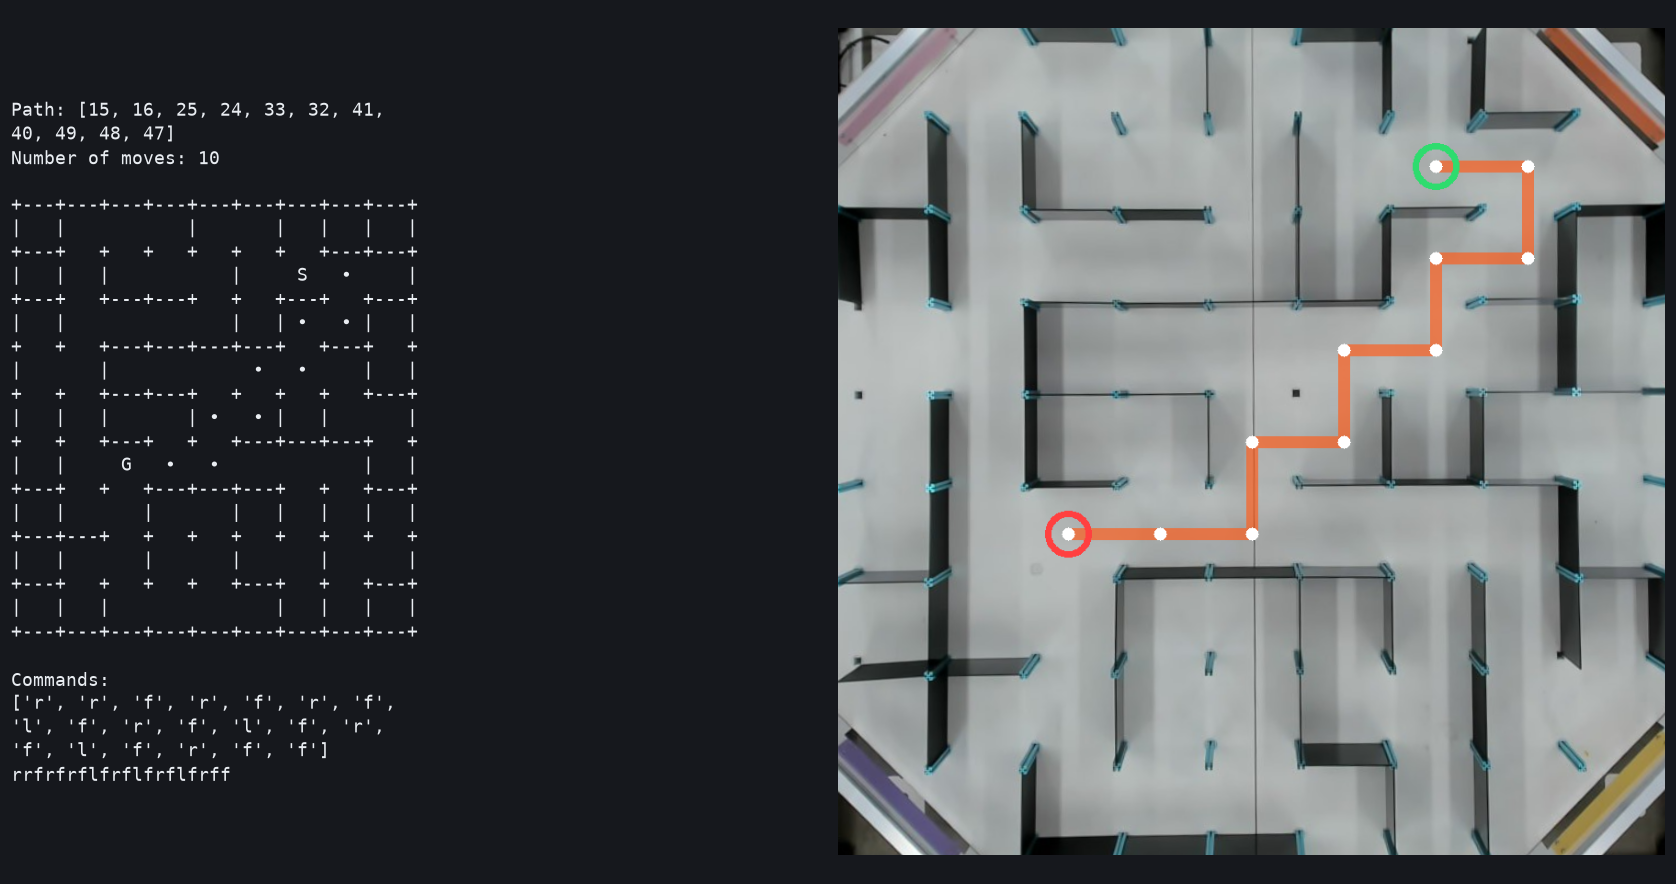

In [52]:
def path_overlay(base, path):
    rgb  = cv2.cvtColor(base, cv2.COLOR_BGR2RGB)
    pts  = [cell_centre(r, c) for r, c in path]

    line = rgb.copy()
    for p, q in zip(pts, pts[1:]):
        cv2.line(line, p, q, (255, 92, 26), 11)
    out = cv2.addWeighted(rgb, .32, line, .68, 0)

    for p in pts:
        cv2.circle(out, p, 7, (255, 255, 255), -1)
    cv2.circle(out, pts[0],  22, (46, 220, 110), 5)
    cv2.circle(out, pts[-1], 22, (255, 64, 64), 5)
    return out


BG, FG = "#16181d", "#e9edf2"
WRAP   = 4 * COLS + 1            # width of the ASCII map, in characters

fig = plt.figure(figsize=(16, 8), facecolor=BG)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.02], wspace=.02,
                        left=.03, right=.97, top=.99, bottom=.01)

ax = fig.add_subplot(gs[0]); ax.axis("off"); ax.set_facecolor(BG)
report = "\n".join([
    textwrap.fill(f"Path: {[maze.node_id(*c) for c in path]}", WRAP),
    f"Number of moves: {len(path) - 1}",
    "",
    maze.ascii(path, START, GOAL),
    "",
    "Commands:",
    textwrap.fill(str(commands), WRAP),
    textwrap.fill(command_string, WRAP),
])
ax.text(0, .5, report, family="monospace", fontsize=11.5, color=FG,
        va="center", ha="left", linespacing=1.35, transform=ax.transAxes)

ax2 = fig.add_subplot(gs[1]); ax2.axis("off")
ax2.imshow(path_overlay(maze_img, path))

plt.show()

## Stage 10 — hand it to the firmware

Writes `maze_route.h` next to the notebook: drop it in `src/task4_code/` and call
`chainMovement(mouse, MAZE_ROUTE)`.

In [53]:
def export_header(filename, command_string, path, maze, start, start_heading, goal, source):
    # keep the header pure ASCII so it is safe in C++ source
    art  = maze.ascii(path, start, goal).replace(PATH_DOT, "*").splitlines()
    body = "\n".join(f"//   {row}" for row in art)
    text = f"""#pragma once

// Generated by task4_code/image_processing.ipynb from {source}
// {maze.rows}x{maze.cols} maze (rows x cols).
// Start {start} facing {start_heading}  ->  goal {goal}, {len(path) - 1} moves.
//
{body}
//
// Usage:  chainMovement(mouse, MAZE_ROUTE);

constexpr int   MAZE_ROWS     = {maze.rows};
constexpr int   MAZE_COLS     = {maze.cols};
constexpr int   MAZE_MOVES    = {len(path) - 1};
constexpr char  MAZE_START_DIR = '{start_heading}';
constexpr char  MAZE_ROUTE[]  = "{command_string}";
"""
    with open(filename, "w", encoding="utf-8") as f:
        f.write(text)
    return text


print(export_header("maze_route.h", command_string, path, maze,
                    START, START_HEADING, GOAL, PHOTO))

#pragma once

// Generated by task4_code/image_processing.ipynb from maze_1.jpg
// 9x9 maze (rows x cols).
// Start (1, 6) facing W  ->  goal (5, 2), 10 moves.
//
//   +---+---+---+---+---+---+---+---+---+
//   |   |           |       |   |   |   |
//   +---+   +   +   +   +   +   +---+---+
//   |   |   |           |     S   *     |
//   +---+   +---+---+   +   +---+   +---+
//   |   |               |   | *   * |   |
//   +   +   +---+---+---+---+   +---+   +
//   |       |             *   *     |   |
//   +   +   +---+---+   +   +   +   +---+
//   |   |   |       | *   * |   |       |
//   +   +   +---+   +   +---+---+---+   +
//   |   |     G   *   *             |   |
//   +---+   +   +---+---+---+   +   +---+
//   |   |       |       |   |   |   |   |
//   +---+---+   +   +   +   +   +   +   +
//   |   |       |       |       |       |
//   +---+   +   +   +   +---+   +   +---+
//   |   |   |               |   |   |   |
//   +---+---+---+---+---+---+---+---+---+
//
// Usage:  chainM

## Everything above, in one call

Re-shoot the maze, drop the photo in this folder, and run this on it.

In [ ]:
def solve_photo(filename, start, heading, goal, final_heading=None, show=True):
    """photo -> (command string, path, Maze). Raises if no route exists.

    Works for any rows x cols maze; both are measured from the photo.
    """
    img = cv2.imread(filename)
    if img is None:
        raise FileNotFoundError(filename)

    to_rig     = square_transform(find_rig_quad(img), COARSE_PX)
    coarse_img = cv2.warpPerspective(img, to_rig, (COARSE_PX, COARSE_PX))

    xs, ys = infer_grid(find_clips(coarse_img))
    cols, rows = len(xs) - 1, len(ys) - 1
    if rows < 2 or cols < 2:
        raise RuntimeError(f"implausible {rows} x {cols} grid from {filename}")

    quad = np.float32([[xs[0], ys[0]], [xs[-1], ys[0]], [xs[-1], ys[-1]], [xs[0], ys[-1]]])
    w, h = cols * CELL_PX, rows * CELL_PX
    to_grid = cv2.getPerspectiveTransform(
        quad, np.float32([[0, 0], [w, 0], [w, h], [0, h]]))
    rect = cv2.warpPerspective(img, to_grid @ to_rig, (w, h))

    hw, vw, *_ = build_walls(wall_pixels(rect), rows, cols)
    m = Maze(hw, vw)

    for name, cell in (("start", start), ("goal", goal)):
        if not m.inside(*cell):
            raise ValueError(f"{name} {cell} is outside the {rows}x{cols} maze in {filename}")

    route = m.bfs(start, goal)
    if route is None:
        raise RuntimeError(f"no route from {start} to {goal} in {filename}")

    cmds, end = path_to_commands(route, heading, final_heading)
    landed, _ = replay(m, start, cmds, heading)
    assert landed == goal, f"replay ended at {landed}, expected {goal}"

    if show:
        print(f"{filename}: {rows} rows x {cols} cols")
        print(m.ascii(route, start, goal))
        print(f"\n{len(route) - 1} moves, facing {heading} -> {end}:  {''.join(cmds)}")
    return "".join(cmds), route, m


_ = solve_photo(PHOTO, START, START_HEADING, GOAL)

# photo_file = "maze_1.jpg"
# start_coord = (0, 3)
# start_orientation = "E" 
# goal_coord = (8, 5)
# solve_photo(photo_file, start_coord, start_orientation, goal_coord)

maze_1.jpg: 9 rows x 9 cols
+---+---+---+---+---+---+---+---+---+
|   | •   •   S |       |   |   |   |
+---+   +   +   +   +   +   +---+---+
|   | • |           |               |
+---+   +---+---+   +   +---+   +---+
|   | •             |   |       |   |
+   +   +---+---+---+---+   +---+   +
|     • |                       |   |
+   +   +---+---+   +   +   +   +---+
|   | • |       |       |   |       |
+   +   +---+   +   +---+---+---+   +
|   | •   •                     |   |
+---+   +   +---+---+---+   +   +---+
|   |     • |       |   |   |   |   |
+---+---+   +   +   +   +   +   +   +
|   |     • |       |       |       |
+---+   +   +   +   +---+   +   +---+
|   |   | •   •   •   G |   |   |   |
+---+---+---+---+---+---+---+---+---+

14 moves, facing E -> E:  rrfflffffflfrffflfff


('rrfflffffflfrffflfff',
 [(0, 3),
  (0, 2),
  (0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (5, 2),
  (6, 2),
  (7, 2),
  (8, 2),
  (8, 3),
  (8, 4),
  (8, 5)],
 <__main__.Maze at 0x20d0a0a5150>)

## Picking `START` and `GOAL` — the labelled grid

Every cell drawn on the photo with its `(row, col)` label, using the grid lines
measured back in Stage 2. Row 0 is the top of the photo and column 0 the left, the
same convention `START`/`GOAL` at the top of the notebook use — read a pair off
this picture, put it up there, and re-run.

The green box shows where `START` and `GOAL` currently sit.

In [ ]:
import io

from matplotlib.figure import Figure
from matplotlib.patches import Rectangle
from matplotlib import patheffects
from IPython.display import display, Image

MAX_LABELS = 2000     # a real board is ~81 cells; near this means Stage 2 misread the clips


def show_cell_labels(img, xs, ys, mark=(), title=None):
    """Overlay the measured grid on `img` and label every cell with its (row, col).

    `xs`/`ys` are the grid lines from Stage 2, so the labels land on the same cells
    the wall scoring uses. `mark` is an optional list of (label, (r, c)) to ring.

    Drawn on a bare `Figure` rather than through pyplot, so no GUI window is ever
    created and no figure is left open: this returns straight away whichever
    backend the kernel happens to be on.
    """
    rows, cols = len(ys) - 1, len(xs) - 1
    if rows < 1 or cols < 1 or rows * cols > MAX_LABELS:
        raise RuntimeError(f"{rows} x {cols} grid from the clip clustering - too many "
                           "lines to label, re-run Stage 2 and check CLIP_TOL")

    pitch = min(np.diff(xs).mean(), np.diff(ys).mean())
    outline = [patheffects.withStroke(linewidth=2.5, foreground="white")]

    fig = Figure(figsize=(9, 9 * rows / cols), dpi=plt.rcParams["figure.dpi"])
    ax = fig.add_subplot(111)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    for x in xs:
        ax.plot([x, x], [ys[0], ys[-1]], color="#1e90ff", lw=1.6)
    for y in ys:
        ax.plot([xs[0], xs[-1]], [y, y], color="#1e90ff", lw=1.6)

    for r in range(rows):
        for c in range(cols):
            ax.text((xs[c] + xs[c + 1]) / 2, (ys[r] + ys[r + 1]) / 2, f"{r},{c}",
                    color="#ff3b1f", fontsize=pitch * 0.13, fontweight="bold",
                    ha="center", va="center", path_effects=outline)

    for name, (r, c) in mark:
        ax.add_patch(Rectangle((xs[c], ys[r]), xs[c + 1] - xs[c], ys[r + 1] - ys[r],
                               fill=False, edgecolor="#2ee06e", lw=3))
        ax.text((xs[c] + xs[c + 1]) / 2, ys[r] + pitch * 0.22, name, color="#2ee06e",
                fontsize=pitch * 0.11, fontweight="bold", ha="center", va="center",
                path_effects=outline)

    ax.set_title(title or f"Choose coordinates from this labelled {rows} x {cols} grid")
    ax.axis("off")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    display(Image(data=buf.getvalue()))


show_cell_labels(coarse, gx, gy, mark=[("START", START), ("GOAL", GOAL)])
print(f"START = {START} facing {START_HEADING}   GOAL = {GOAL}   ({ROWS} rows x {COLS} cols)")